# Week 5

Before you start working on today's class, take 10 minutes to fill in the mid-term feedback form on DTU Learn: 
[Week 5 - Mid-term Feedback Form](https://learn.inside.dtu.dk/d2l/lms/survey/user/surveys_list.d2l?ou=296278) Your feedback is super important for me. It helps me get a feeling for how things are going and what I can do to make the class better. So, please, make sure to fill it!! The survey is anonymous. 


# Overview

This week we'll talk about some of the charachteristics of real-world social networks. The structure is the following: 

* __Part 1: Introduction to heavy tailed distributions.__ We will begin with a brief overview of heavy tailed distributions, emphasizing their importance in social systems. Understanding these distributions is crucial as they frequently emerge in the analysis of social networks, a theme we will revisit in subsequent exercises.

* __Part 2: Properties real-world social networks.__ We will delve into some of features that charachterize social networks. 

* __Part 3: Analyzing the Network of Computational Social Scientists__ We will turn our attention to the specific network of Computational Social Scientists. Here, the focus will be on investigating and understanding the properties of this network based on the concepts learned in the previous sections.


> *Reading*: Read [Chapter 3 of the Network Science book.](http://networksciencebook.com/chapter/3). The most important sections are 3.1 to 3.4 and 3.8 to 3.10, so focus on that.

# Part 1 : Heavy tailed distributions

When it comes to real-world data, it is very common to observe distributions that are so-called "Heavy tailed". In this section, we will explore this concept a bit more in detail. 
We will start by watching a video-lecure by me. 

> *Video Lecture*: [Heavy tailed distributions](https://www.youtube.com/watch?v=S2OZBTKx8_E)


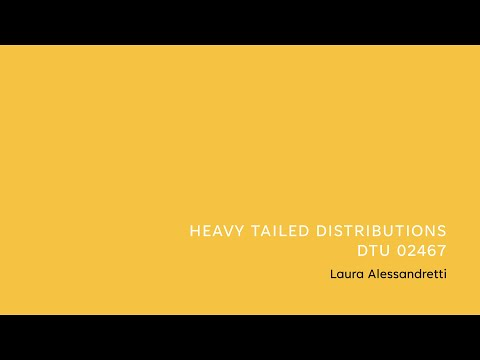

In [1]:
from IPython.display import YouTubeVideo
YouTubeVideo("S2OZBTKx8_E",width=800, height=450)

In this exercise, we'll delve into the impact of heavy-tailed distributions on the reliability of sample averages as estimators for the population mean, a concept discussed in our lecture.

This idea is rooted in [the Law of Large Numbers](https://en.wikipedia.org/wiki/Law_of_large_numbers), which posits that the average of a sufficiently large sample from a distribution with a finite expected value will converge to the population mean. 
However, this principle can fail with heavy-tailed distributions where the expected value may not be finite or the convergence of the sample mean to the population mean can be slow due to high variance.


>__Exercise 1: Law of large numbers__. 
> 
> 1. Sample __N=10,000__ data points from a [Gaussian Distribution](https://en.wikipedia.org/wiki/Normal_distribution) with parameters $\mu = 0 $ and $\sigma = 4$, using the [`np.random.standard_normal()`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.standard_normal.html) function. Store your data in a numpy array $\mathbf{X}$. 
> 2. Create a figure. 
>    - Plot the distribution of the data in $\mathbf{X}$. 
> 3. Compute the cumulative average of $\mathbf{X}$ (you achieve this by computing $average(\{\mathbf{X}[0],..., \mathbf{X}[i-1]\})$ for each index $i \in [1, ..., N+1]$  ). Store the result in an array. 
> 4. In a similar way, compute the cumulative standard error of $\mathbf{X}$. __Note__: the standard error of a sample is defined as $ \sigma_{M} = \frac{\sigma}{\sqrt(n)} $, where $\sigma$ is the sample standard deviation and $n$ is the sample size. Store the result in an array. 
> 5. Compute the values of the distribution mean and median using the formulas you can find on the [Wikipedia page of the Gaussian Distribution](https://en.wikipedia.org/wiki/Normal_distribution)  
> 6. Create a figure. 
>     - Plot the cumulative average computed in point 3. as a line plot (where the x-axis represent the size of the sample considered, and the y-axis is the average).
>     - Add errorbars to each point in the graph with width equal to the standard error of the mean (the one you computed in point 4). 
>     - Add a horizontal line corresponding to the distribution mean (the one you found in point 5).
> 7.  Compute the cumulative median of $\mathbf{X}$ (you achieve this by computing $median(\{\mathbf{X}[0],..., \mathbf{X}[i-1]\})$ for each index $i \in [1, ..., N+1]$). Store the result in an array. 
> 8. Create a figure. 
>    - Plot the cumulative median computed in point 7. as a line plot (where the x-axis represent the size of the sample considered, and the y-axis is the average).
>    - Add a horizontal line corresponding to the distribution median (the one you found in point 5).
>    - _Optional:_ Add errorbars to your median line graph, with width equal to the standard error of the median. You can compute the standard error of the median [via bootstrapping](https://en.wikipedia.org/wiki/Bootstrapping_(statistics)). 
> 9. Now sample __N = 10,000__ data points from a [Pareto Distribution](https://en.wikipedia.org/wiki/Pareto_distribution) with parameters $x_m=1$ and $\alpha=0.5$ using the [`np.random.pareto()`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.pareto.html) function, and store it in a numpy array. (_Optional:_ Write yourself the function to sample from a Pareto distribution using the [_Inverse Transform Sampling method_](https://en.wikipedia.org/wiki/Inverse_transform_sampling))
> 10. Repeat points 2 to 8 for the Pareto Distribution sample computed in point 9. 
> 11. Now, consider your _paper_ dataset (the one you created in Week 3). First, compute the mean and median number of citations for this population. Then, extract a random sample of __N=10,000__ papers.  
> 12. Repeat points 2,3,4,6,7 and 8 above for the paper citation sample prepared in point 11.     
> 13. Reflect on the following questions based on your analysis (__Hint__: I suggest you plot the graphs above multiple times for different random samples, to get a better understanding of what is going on):     
>
> - Compare the behavior of the cumulative average for Gaussian and Pareto distributions. What differences do you notice, and how do they align with your expectations?    
> - Assess the cumulative median against the cumulative average across the two distributions. What insights can you gather about the utility of mean versus median in these contexts?    
> - Based on your citation count data analysis, what observations can you make? What implications do these observations have?    
> - Conclude with your key takeaways from this exercise.
>


### 1

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)  # for reproducibility

In [3]:
N = 10000

# Sample and save as np array
X = 4 * np.random.standard_normal(N)

# Basic statistics
print("Mean:", np.mean(X))
print("Standard deviation:", np.std(X))

Mean: -0.008543933473704862
Standard deviation: 4.01364882451995


### 2

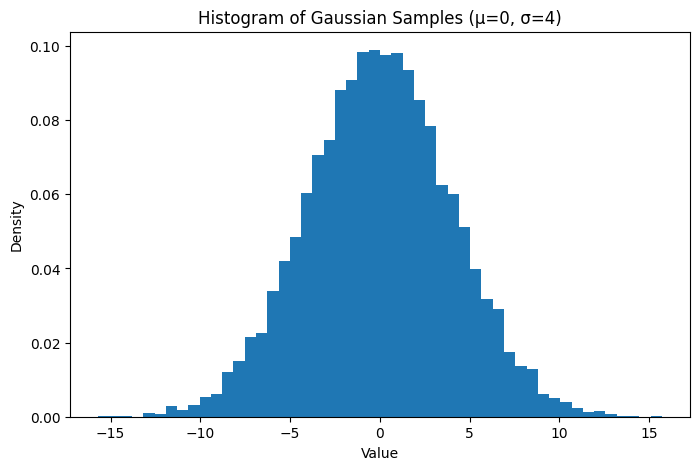

In [4]:
plt.figure(figsize=(8,5))

plt.hist(X, bins=50, density=True)
plt.title("Histogram of Gaussian Samples (μ=0, σ=4)")
plt.xlabel("Value")
plt.ylabel("Density")

plt.show()

### 3

In [5]:
# Cumulative sample sizes: 1 to 10k
n = np.arange(1, N + 1)

# Cumulative sum
cumsum_X = np.cumsum(X)

# Cumulative average
cum_avg = cumsum_X / n

# Quick check
cum_avg[:5]

array([1.98685661, 0.7168997 , 1.34151785, 2.52916825, 1.8360119 ])

### 4

In [6]:
# Cumulative sum of squares
cumsum_X2 = np.cumsum(X**2)

# Cumulative variance using formula:
# Var = (1/n) * sum(X^2) - (mean)^2
cum_var = (cumsum_X2 / n) - (cum_avg**2)

# Numerical safety (avoid tiny negative values from floating point)
cum_var = np.maximum(cum_var, 0)

# Cumulative standard deviation
cum_std = np.sqrt(cum_var)

# Cumulative standard error
cum_se = cum_std / np.sqrt(n)

# Quick check
cum_se[:5]

array([0.        , 0.89799514, 0.78644546, 1.18565988, 1.13317155])

### 5

In [7]:
# Basic statistics
print("Mean:", np.mean(X))
print("Standard deviation:", np.std(X))

Mean: -0.008543933473704862
Standard deviation: 4.01364882451995


### 7

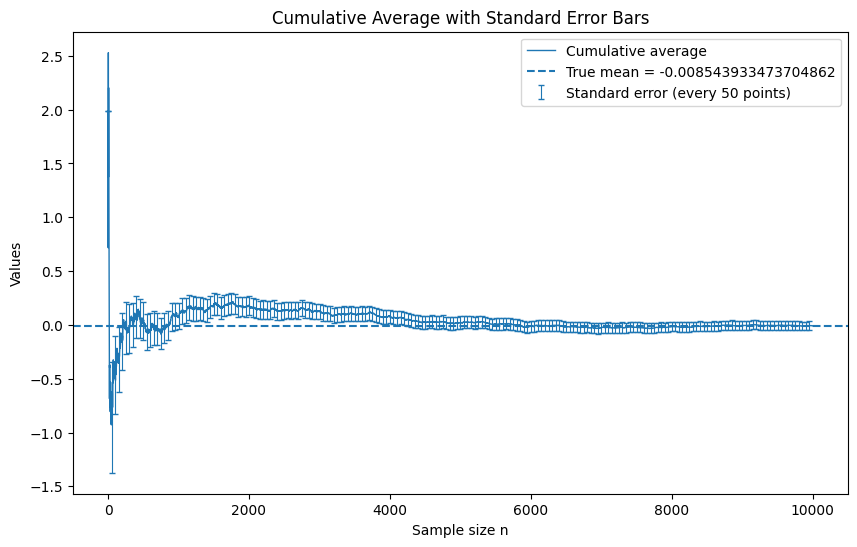

In [8]:
plt.figure(figsize=(10, 6))

# Line plot: cumulative average
plt.plot(n, cum_avg, linewidth=1, label="Cumulative average")

# Error bars (subsample for readability/performance)
step = 50  # set to 1 to draw an errorbar at every point
idx = np.arange(0, N, step)

plt.errorbar(
    n[idx], cum_avg[idx],
    yerr=cum_se[idx],
    fmt="none",
    capsize=2,
    linewidth=0.8,
    label=f"Standard error (every {step} points)"
)

# Horizontal line: true mean
plt.axhline(np.mean(X), linestyle="--", linewidth=1.5, label=f"True mean = {np.mean(X)}")

plt.title("Cumulative Average with Standard Error Bars")
plt.xlabel("Sample size n")
plt.ylabel("Values")
plt.legend()
plt.show()

### 8

In [9]:
cum_median = np.empty(N)

for i in range(1, N + 1):
    cum_median[i-1] = np.median(X[:i])

cum_median[:5]

array([1.98685661, 0.7168997 , 1.98685661, 2.28880538, 1.98685661])

### 9

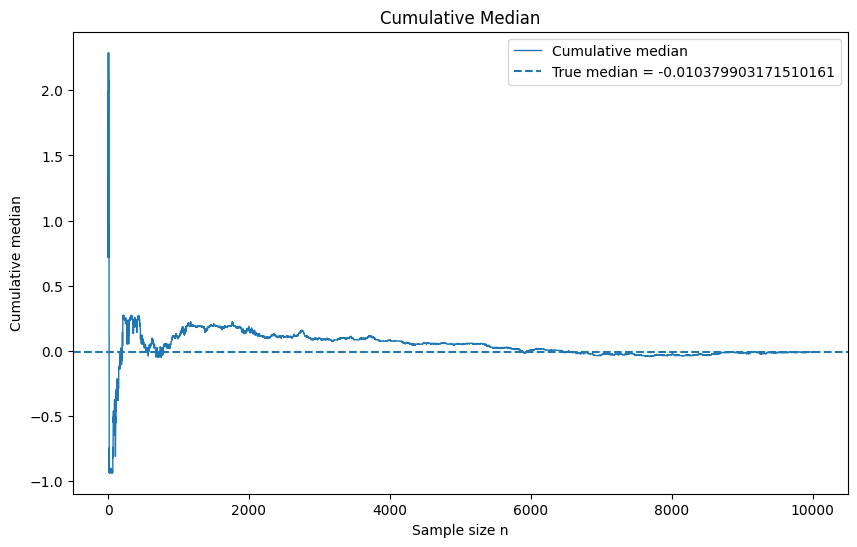

In [10]:
n = np.arange(1, N + 1)

plt.figure(figsize=(10, 6))

plt.plot(n, cum_median, linewidth=1, label="Cumulative median")
plt.axhline(np.median(X), linestyle="--", linewidth=1.5, label=f"True median = {np.median(X)}")

plt.title("Cumulative Median")
plt.xlabel("Sample size n")
plt.ylabel("Cumulative median")
plt.legend()
plt.show()

In [11]:
rng = np.random.default_rng(0)

B = 300          # bootstrap resamples per n (increase for smoother estimates)
step = 200       # compute errorbars every 200 points
idx = np.arange(step, N + 1, step)  # n-values where we estimate SE

se_median = np.empty(len(idx))

for j, m in enumerate(idx):
    sample = X[:m]
    # bootstrap medians
    boots = rng.choice(sample, size=(B, m), replace=True)
    boot_meds = np.median(boots, axis=1)
    se_median[j] = np.std(boot_meds, ddof=1)

se_median[:5], idx[:5]

(array([0.36359667, 0.22892249, 0.19024883, 0.17260527, 0.15251455]),
 array([ 200,  400,  600,  800, 1000]))

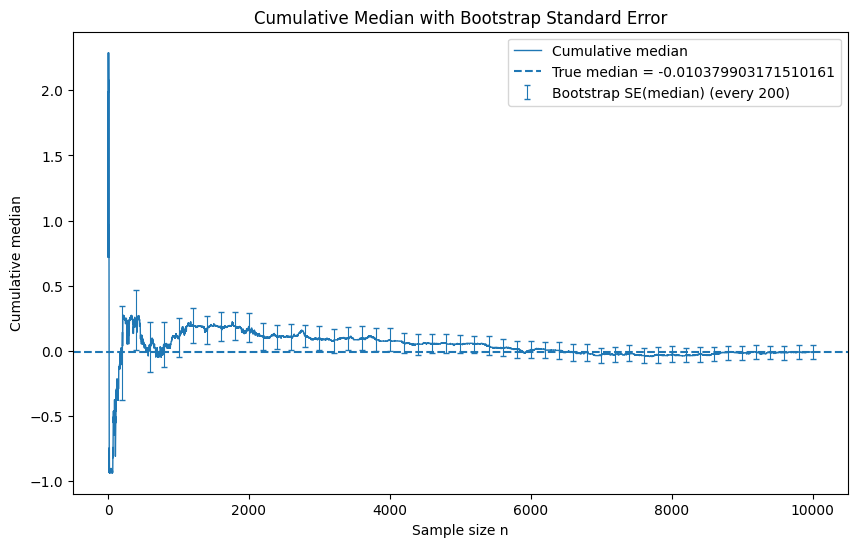

In [12]:
plt.figure(figsize=(10, 6))

plt.plot(n, cum_median, linewidth=1, label="Cumulative median")

# error bars at selected n's
plt.errorbar(
    idx,
    cum_median[idx - 1],   # median at those n values
    yerr=se_median,
    fmt="none",
    capsize=2,
    linewidth=0.8,
    label=f"Bootstrap SE(median) (every {step})"
)

plt.axhline(np.median(X), linestyle="--", linewidth=1.5, label=f"True median = {np.median(X)}")

plt.title("Cumulative Median with Bootstrap Standard Error")
plt.xlabel("Sample size n")
plt.ylabel("Cumulative median")
plt.legend()
plt.show()

### 10

In [13]:
# Parameters
N = 10_000
alpha = 0.5
x_m = 1

# Sample
Y = np.random.pareto(alpha, N)
X_pareto = x_m * (1 + Y)

print("First 5 values:", X_pareto[:5])

First 5 values: [2.17063567 1.24289288 1.16071055 1.21901269 5.74719349]


In [14]:
def sample_pareto_inverse(N, alpha, x_m=1):
    U = np.random.uniform(0, 1, N)
    return x_m * (1 - U) ** (-1 / alpha)

X_pareto_inv = sample_pareto_inverse(N, alpha, x_m)

print("First 5 inverse-sampled values:", X_pareto_inv[:5])

First 5 inverse-sampled values: [   1.456885      2.3437463  1118.68773944   20.80993582    1.94297027]


/var/folders/4p/ys3rkz1x60xcwx4pzd453jt40000gn/T/ipykernel_74206/4274302095.py:8: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 50)  # limit view to see bulk of distribution


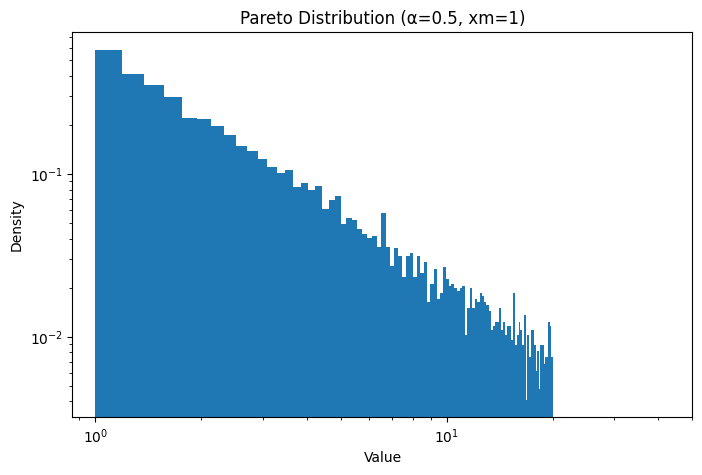

In [15]:
plt.figure(figsize=(8,5))
plt.hist(X_pareto[X_pareto < 20], bins=100, density=True)
plt.title("Pareto Distribution (α=0.5, xm=1)")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Value")
plt.ylabel("Density")
plt.xlim(0, 50)  # limit view to see bulk of distribution
plt.show()

In [16]:
# show heavy tail
print("Max value:", np.max(X_pareto))
print("95th percentile:", np.percentile(X_pareto, 95))
print("99th percentile:", np.percentile(X_pareto, 99))

Max value: 176959673.22315213
95th percentile: 458.5117755315259
99th percentile: 13114.07081466643


In [17]:
n = np.arange(1, N + 1)

# cumulative mean
cum_avg_p = np.cumsum(X_pareto) / n

# cumulative variance
cumsum_X2_p = np.cumsum(X_pareto**2)
cum_var_p = (cumsum_X2_p / n) - (cum_avg_p**2)
cum_var_p = np.maximum(cum_var_p, 0)

cum_std_p = np.sqrt(cum_var_p)
cum_se_p = cum_std_p / np.sqrt(n)

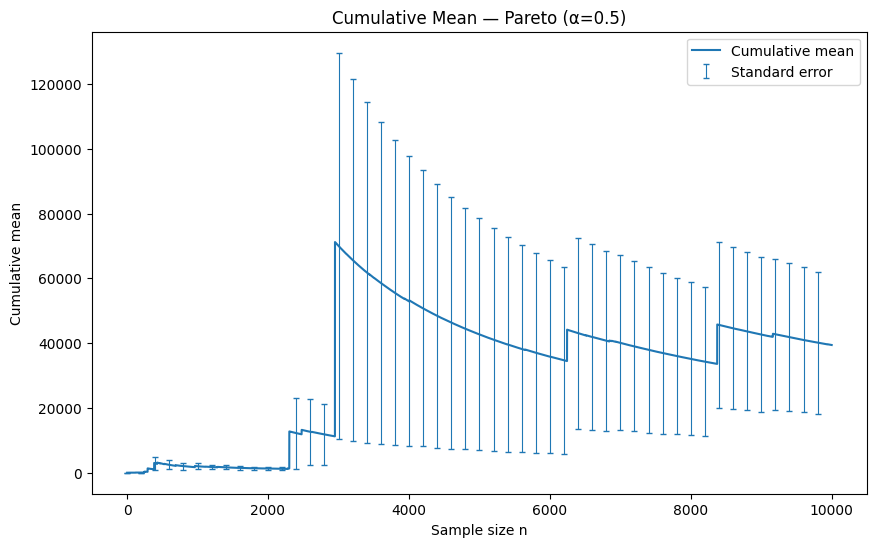

In [18]:
plt.figure(figsize=(10,6))

plt.plot(n, cum_avg_p, label="Cumulative mean")

step = 200
idx = np.arange(0, N, step)

plt.errorbar(
    n[idx],
    cum_avg_p[idx],
    yerr=cum_se_p[idx],
    fmt="none",
    capsize=2,
    linewidth=0.8,
    label="Standard error"
)

plt.title("Cumulative Mean — Pareto (α=0.5)")
plt.xlabel("Sample size n")
plt.ylabel("Cumulative mean")
plt.legend()
plt.show()

In [19]:
cum_median_p = np.empty(N)

for i in range(1, N + 1):
    cum_median_p[i-1] = np.median(X_pareto[:i])

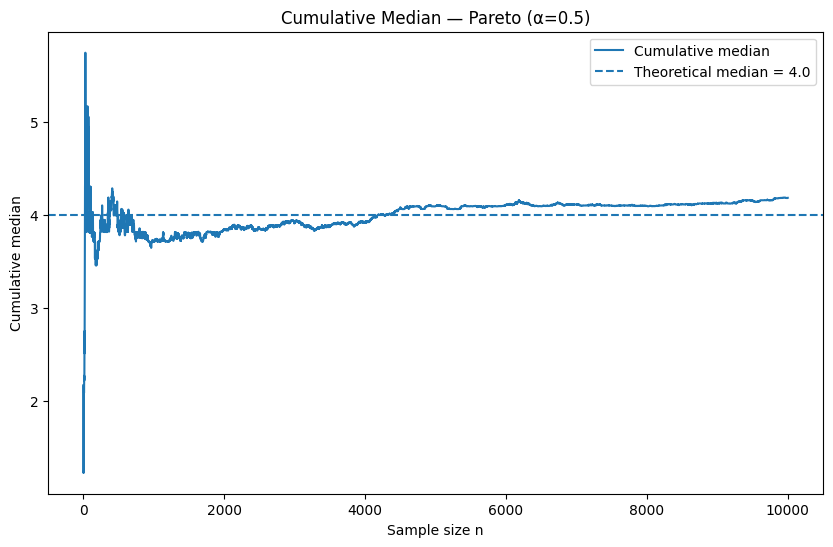

In [20]:
dist_median_p = x_m * 2**(1/alpha)

plt.figure(figsize=(10,6))

plt.plot(n, cum_median_p, label="Cumulative median")
plt.axhline(dist_median_p, linestyle="--", label=f"Theoretical median = {dist_median_p}")

plt.title("Cumulative Median — Pareto (α=0.5)")
plt.xlabel("Sample size n")
plt.ylabel("Cumulative median")
plt.legend()
plt.show()

### 11

In [21]:
import pandas as pd

# Load dataset
df = pd.read_csv("D5_coauthor_papers.csv")

# Extract citation column
citations = df["cited_by_count"].dropna().values

# Population statistics
pop_mean = np.mean(citations)
pop_median = np.median(citations)

print("Population mean citations:", pop_mean)
print("Population median citations:", pop_median)

Population mean citations: 110.91026615969582
Population median citations: 41.0


In [22]:
N = 10_000

sample = np.random.choice(citations, size=N, replace=False)

print("Sample size:", len(sample))

Sample size: 10000


### 12

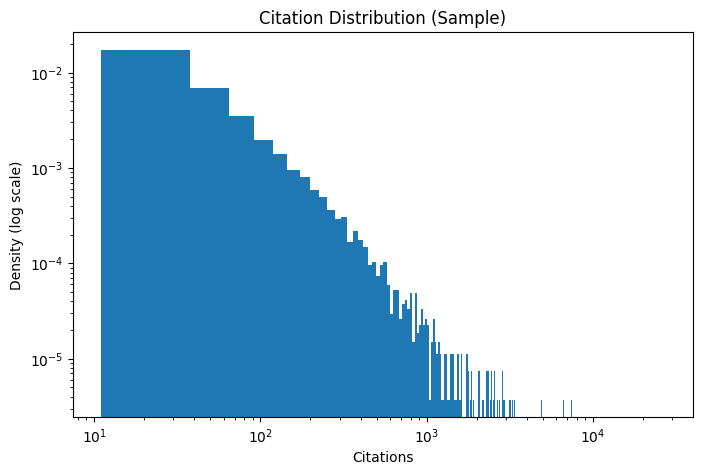

In [31]:
plt.figure(figsize=(8,5))
plt.hist(sample, bins=1000, density=True)
plt.yscale("log")
plt.xscale("log")
plt.title("Citation Distribution (Sample)")
plt.xlabel("Citations")
plt.ylabel("Density (log scale)")
plt.show()

In [24]:
n = np.arange(1, N + 1)

# cumulative mean
cum_avg_c = np.cumsum(sample) / n

# cumulative variance
cumsum_sq = np.cumsum(sample**2)
cum_var_c = (cumsum_sq / n) - (cum_avg_c**2)
cum_var_c = np.maximum(cum_var_c, 0)

cum_std_c = np.sqrt(cum_var_c)
cum_se_c = cum_std_c / np.sqrt(n)

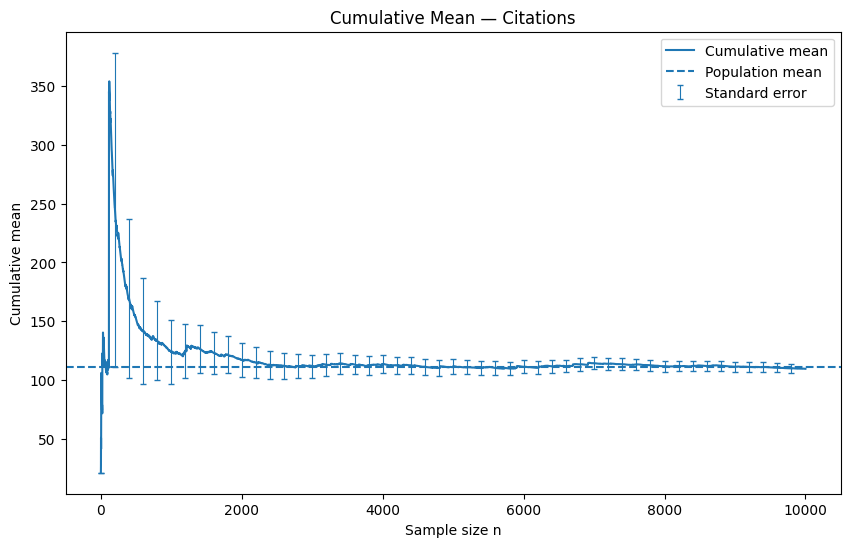

In [25]:
plt.figure(figsize=(10,6))

plt.plot(n, cum_avg_c, label="Cumulative mean")

step = 200
idx = np.arange(0, N, step)

plt.errorbar(
    n[idx],
    cum_avg_c[idx],
    yerr=cum_se_c[idx],
    fmt="none",
    capsize=2,
    linewidth=0.8,
    label="Standard error"
)

plt.axhline(pop_mean, linestyle="--", label="Population mean")

plt.title("Cumulative Mean — Citations")
plt.xlabel("Sample size n")
plt.ylabel("Cumulative mean")
plt.legend()
plt.show()

In [26]:
cum_median_c = np.empty(N)

for i in range(1, N + 1):
    cum_median_c[i-1] = np.median(sample[:i])

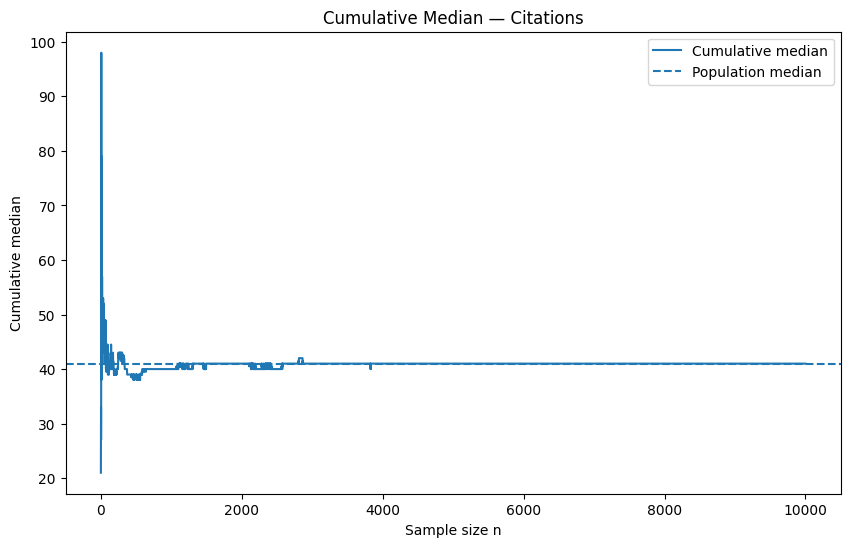

In [27]:
plt.figure(figsize=(10,6))

plt.plot(n, cum_median_c, label="Cumulative median")
plt.axhline(pop_median, linestyle="--", label="Population median")

plt.title("Cumulative Median — Citations")
plt.xlabel("Sample size n")
plt.ylabel("Cumulative median")
plt.legend()
plt.show()

### 13

For the Gaussian distribution:

The cumulative mean stabilizes quickly. Fluctuations shrink smoothly. Error bars decrease at rate 1/sqrt(n).
Convergence is visually clean and predictable.


For the Pareto distribution (α = 0.5):
The cumulative mean jumps wildly. Large outliers cause sudden spikes.
No stable convergence.
Standard error does not meaningfully shrink.

This aligns with the theory:

Gaussian → finite mean and variance → Law of Large Numbers holds.
Pareto (α < 1) → infinite mean → LLN fails.
The mean becomes unstable under extreme heavy tails.

# Part 2 : Empirical properties of real-world social networks

Researchers in Computational Social Science have widely studied the properties of real-world social networks. The very cool thing they found is that many widely different social networks (from face-to-face interactions among classmates, to the Facebook network, to collaboration networks among scientists or actors, etc) present some commonalities. Researchers sometimes refer to those as 'Universalities'.
In the video-lecture below, I will introduce _some_ of the things we know to be true for most real-world social networks. 

> **_Video Lecture_**. Start by watching the ["Properties of empirical social networks"](https://youtu.be/jHdnehLku54). 


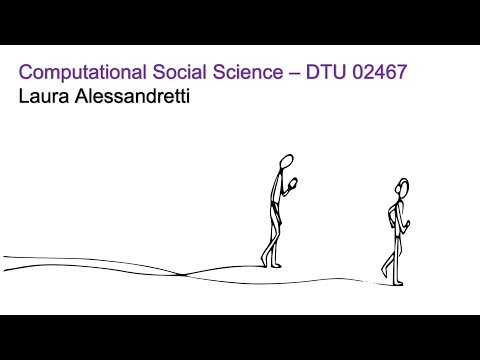

In [28]:
from IPython.display import YouTubeVideo
YouTubeVideo("jHdnehLku54",width=800, height=450)

> __*Exercise 2:* Did you really read the text? Answer the following questions (no calculations needed) in your Jupyter notebook.__
>
> * What's the problem with random networks as a model for real-world networks according to the argument in section 3.5 (near the end)?    
> * List the four regimes that characterize random networks as a function of ⟨k⟩.    
> * According to the book, why is it a problem for random networks (in terms of being a model for real-world networks that the degree-dependent clustering C(k) decreases as a function of k in real-world networks?    

Real-world networks tend to show strong clustering and community structure with degree correlations. They often have heavy-tailed degree distributions while random networks tend to have Poisson degree distributions.
Random networks tend to be too homogenous where nodes have a similar degree. Another issue is that structure emerges from chance rather than underlying organic principles. Therefore, the random networks do not capture the heterogeneity and organization seen in real-world networks.

As the average degree ⟨k⟩ increases, random networks transition through four regimes:

⟨k⟩ < 1 — Subcritical regime

The network consists of many small disconnected components.No giant component exists.

⟨k⟩ = 1 — Critical point

A phase transition occurs. A giant component begins to emerge.

⟨k⟩ > 1 — Supercritical regime

A giant connected component exists. Most nodes belong to it. Small isolated clusters still remain.

⟨k⟩ ≫ 1 (roughly ⟨k⟩ > ln(N)) — Connected regime

The network becomes fully connected with high probability. Almost all nodes belong to one connected component.

These regimes reflect a phase-transition-like behavior in connectivity.

In real-world networks, the clustering coefficient often depends on degree:
$$C(k) \sim k^{-1}$$

The implication of this is that low-degree nodes often belong to tightly knit communities and high degree nodes (hubs) connect across communities. Essentially, networks are hierarchical and modular. In contrast, random networks have clustering independent of degree, $C(k)$ is roughly constant, and there is no hierarchical organization. This poses an issue since it means that random networks are unable to reproduce this degree-dependent clustering and therefore fail to capture an essential organizing principle of real networks.

# Part 3: Properties of the real-world network of Computational Social Scientists


> __Exercise 3: Analyzing Networks through a Random Model__
>

>
> 2.1 _Random Network_: Let's start by building a Random Network, acting as a baseline (or ["null model"](https://en.wikipedia.org/wiki/Null_model)) to understand the Computational Social Scientists Network better.  
>
> * First, calculate the probability (_p_) that makes the expected number of edges in our random network match the actual edge count in the Computational Social Scientists network. Refer to equation 3.2 in your Network Science textbook for guidance. After finding _p_, figure out the average degree (using the given formula). 
> * Now, write a function to generate a Random Network that mirrors the Computational Social Scientists network in terms of node count, using your calculated _p_. Generate a random network by linking nodes in every possible pair with probability _p_. **Hint**: you can use the function [``np.random.uniform``](https://numpy.org/doc/stable/reference/random/generated/numpy.random.uniform.html) to draw samples from a uniform probability distribution.   
> * Visualize the network as you did for the Computational Social Scientists network in the exercise above (my version is below). 
>
> * Answer the following questions:  
>.   
>    - What regime does your random network fall into? Is it above or below the critical threshold?   
>    - According to the textbook, what does the network's structure resemble in this regime?  
>    - Based on your visualizations, identify the key differences between the actual and the random networks. Explain whether these differences are consistent with theoretical expectations.    
>
>   
> 2.2 _Degree Distribution_: This section focuses on analyzing the degree distribution of both the actual Computational Social Scientists network and its random counterpart.
>
> * Compute the distribution of degree for the random network using the numpy function ``np.histogram``. Choose bins, and normalization strategies appropriately. **Hint:** Revisit the content from Week 3, Part 3 of the lectures.  
> * Compute the distribution of degree for the Computational Social Scientists network using the numpy function ``np.histogram``. Also here, choose bins and normalization strategies wisely, based on the recommendations from previous lectures.
> * Plot both degree distributions on the same figure using line plots, ensuring the x and y axes are scaled in a way that allows for comparison between the two distributions.
> * Add two vertical lines showing the average degree for the random and the real network. 
> * Answer the following questions: 
>    - Does the average degree meaningfully represents the network's characteristics, especially in light of the insights gained from exploring heavy-tailed distributions? Discuss its adequacy or limitations in capturing the essence of the network's structural properties.
>    - What differences can you observe between the real and the random distributions? How does the shape of the degree distribution for each network inform us about the network's properties?
>
>
>   
>
> 2.3 _Shortest Paths_: Here, we will check if the Computational Social Scientists Network exhibits characteristics of a small-world network by analyzing its shortest paths.
>
> * Begin by identifying the largest connected component within the Computational Social Scientists network. Recall that a connected component is a subset of nodes in which every pair of nodes is connected by a path. For a refresher on connected components, see section 2.9 of the Network Science book. Follow these steps:
>    - Utilize [``nx.algorithms.connected_components``](https://networkx.org/documentation/stable//reference/algorithms/generated/networkx.algorithms.components.connected_components.html) to enumerate all connected components, which will be returned as a list of node subsets.
>    - Select the largest subset of nodes identified in the previous step. Then, create a subgraph of your original network that includes only these nodes, using [``nx.Graph.subgraph``](https://networkx.org/documentation/stable/reference/classes/generated/networkx.Graph.subgraph.html). This subset forms your largest connected component, sometimes referred to as the [giant component](https://en.wikipedia.org/wiki/Giant_component).
> * Calculate the average (unweighted) shortest path length within this giant component by employing [``nx.average_shortest_path_length``](https://networkx.org/documentation/networkx-1.3/reference/generated/networkx.average_shortest_path_length.html). 
> * Perform the same calculation for the giant component of the random network you constructed in exercise 2.1.
> * Reflect on how the average shortest path lengths of the real and random networks compare and answer the following questions, supporting your answers with the theory from the book.   
>    
>   - Why do you think I asked you to consider the giant component only?  
>   - Why do you think I asked you to consider unweighted edges?    
>   - Does the Computational Social Scientists network exhibit the small-world phenomenon?    



In [36]:
import json
import networkx as nx

# Load the Computational Social Scientists network
with open("css_network.json", "r") as f:
    data = json.load(f)
    
# Try to read into NetworkX (assuming node/edge list or graph-serialized JSON)
# If it's node-link data produced by nx.readwrite.node_link_data, try node_link_graph
try:
    G_real = nx.node_link_graph(data)
except Exception:
    # fallback: try edge list format
    try:
        G_real = nx.readwrite.json_graph.node_link_graph(data)
    except Exception as e:
        raise RuntimeError("Couldn't parse css_network.json automatically. Inspect the file format.") from e

print("Loaded graph:")
print(" nodes:", G_real.number_of_nodes())
print(" edges:", G_real.number_of_edges())

Loaded graph:
 nodes: 21693
 edges: 87076


In [37]:
# Code cell
n = G_real.number_of_nodes()
m = G_real.number_of_edges()

# For undirected simple graph expected edges in G(n,p): E[m] = p * n*(n-1)/2
p = (2.0 * m) / (n * (n - 1))

# Average degree (theoretical for G(n,p)): <k> = p*(n-1)  (also 2m/n empirical)
avg_degree_theoretical = p * (n - 1)
avg_degree_empirical = 2.0 * m / n

print(f"n = {n}, m = {m}")
print(f"p (matching expected edges) = {p:.5e}")
print(f"theoretical <k> = {avg_degree_theoretical:.4f}")
print(f"empirical <k> = {avg_degree_empirical:.4f}  (2m/n)")

n = 21693, m = 87076
p (matching expected edges) = 3.70092e-04
theoretical <k> = 8.0280
empirical <k> = 8.0280  (2m/n)


In [38]:
# Code cell
def generate_random_graph_matching_m(n_nodes, p, seed=None):
    """
    Generate undirected simple random graph with n_nodes where each pair is connected
    with probability p. Implementation uses the upper-triangle sampling with np.random.uniform.
    Returns a NetworkX Graph.
    """
    rng = np.random.default_rng(seed)
    G = nx.Graph()
    G.add_nodes_from(range(n_nodes))
    # Generate upper triangular mask
    # We'll iterate pairs but in a vectorized-ish manner to avoid n^2 python loops when possible.
    # For moderate n this approach is fine.
    for i in range(n_nodes):
        # sample probabilities for edges (i, j) for j > i
        k = n_nodes - (i + 1)
        if k <= 0:
            continue
        r = rng.uniform(0, 1, size=k)
        js = np.nonzero(r < p)[0] + (i + 1)
        for j in js:
            G.add_edge(i, int(j))
    return G

# Generate one random graph (use seed for reproducibility)
G_rand = generate_random_graph_matching_m(n, p, seed=42)
print("Random graph: nodes:", G_rand.number_of_nodes(), "edges:", G_rand.number_of_edges())
print("average degree (random graph, empirical):", sum(dict(G_rand.degree()).values())/n)

Random graph: nodes: 21693 edges: 87475
average degree (random graph, empirical): 8.064813534319827


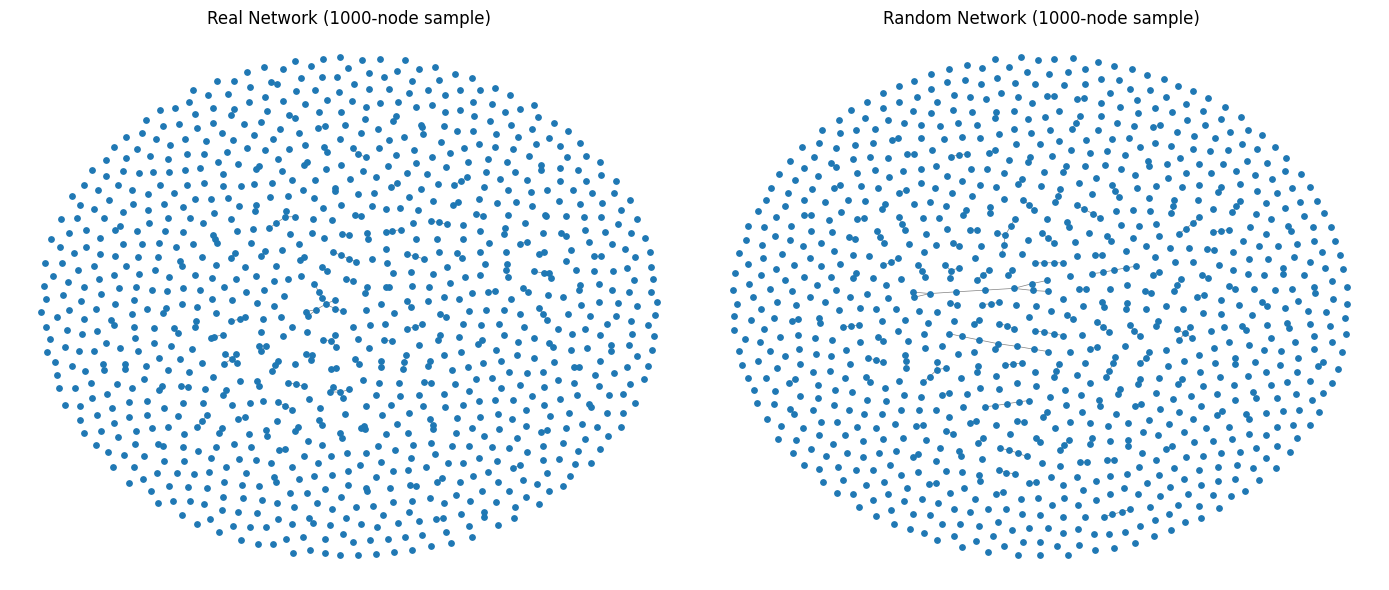

In [48]:
# Number of nodes to visualize
k = 1000

# Sample same number of nodes from each network
subset_real = np.random.choice(list(G_real.nodes()), size=k, replace=False)
subset_rand = np.random.choice(list(G_rand.nodes()), size=k, replace=False)

G_real_small = G_real.subgraph(subset_real)
G_rand_small = G_rand.subgraph(subset_rand)

plt.figure(figsize=(14,6))

# --- Real network ---
plt.subplot(1,2,1)
pos_real = nx.spring_layout(G_real_small, seed=1)
nx.draw(G_real_small, pos_real,
        node_size=15,
        edge_color="gray",
        width=0.5)
plt.title("Real Network (1000-node sample)")
plt.axis("off")

# --- Random network ---
plt.subplot(1,2,2)
pos_rand = nx.spring_layout(G_rand_small, seed=1)
nx.draw(G_rand_small, pos_rand,
        node_size=15,
        edge_color="gray",
        width=0.5)
plt.title("Random Network (1000-node sample)")
plt.axis("off")

plt.tight_layout()
plt.show()

### Check regime

In [49]:
# Critical point for emergence of giant component in G(n,p) is <k> = 1 (i.e., p*(n-1) = 1)
critical_threshold = 1.0
k_rand = avg_degree_theoretical
regime = "supercritical" if k_rand > critical_threshold else ("critical" if np.isclose(k_rand, 1) else "subcritical")

print("Random graph average degree (theoretical):", k_rand)
print("Critical threshold <k>=1 =>", "Regime =", regime)
if regime == "subcritical":
    print("- Expect many small components, no giant component.")
elif regime == "critical":
    print("- Expect emergence of giant component (phase transition).")
else:
    print("- Expect a giant connected component, random-like structure (locally tree-like if sparse).")

Random graph average degree (theoretical): 8.028027474300465
Critical threshold <k>=1 => Regime = supercritical
- Expect a giant connected component, random-like structure (locally tree-like if sparse).


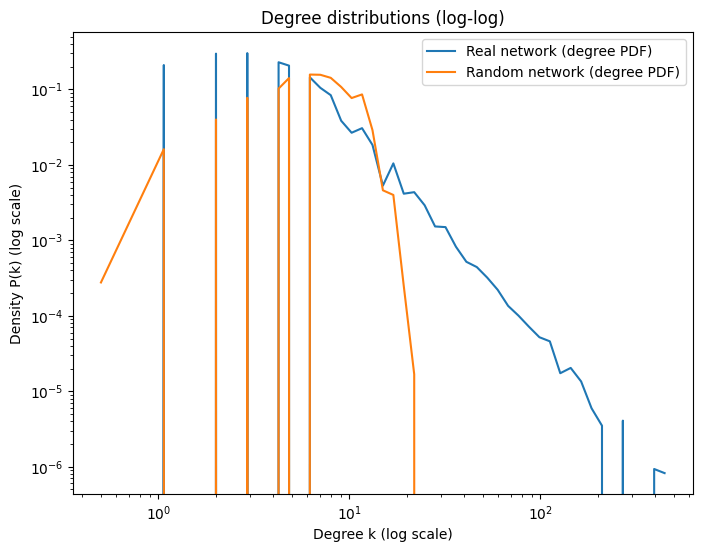

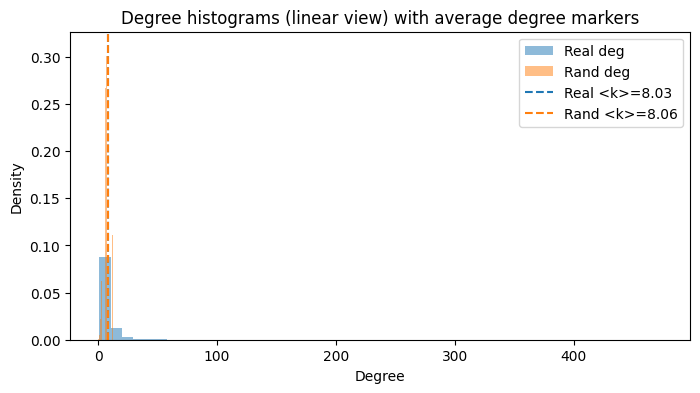

In [50]:
# Degree sequences
deg_real = np.array([d for _, d in G_real.degree()])
deg_rand = np.array([d for _, d in G_rand.degree()])

# Choose bins suitable for skewed distributions: use log-spaced bins for heavy tail comparison
max_deg = max(deg_real.max(), deg_rand.max())
bins = np.unique(np.logspace(0, np.log10(max_deg + 1), num=50))  # from 1 to max_deg in log-space
# but ensure degree 0 handled
bins = np.insert(bins, 0, 0)

hist_r, bin_edges = np.histogram(deg_real, bins=bins, density=True)
hist_rand, _ = np.histogram(deg_rand, bins=bin_edges, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

plt.figure(figsize=(8,6))
plt.plot(bin_centers, hist_real := hist_r, label="Real network (degree PDF)")
plt.plot(bin_centers, hist_rand, label="Random network (degree PDF)")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Degree k (log scale)")
plt.ylabel("Density P(k) (log scale)")
plt.title("Degree distributions (log-log)")
plt.legend()
plt.show()

# vertical lines for average degree
plt.figure(figsize=(8,4))
plt.hist(deg_real, bins=50, alpha=0.5, label="Real deg", density=True)
plt.hist(deg_rand, bins=50, alpha=0.5, label="Rand deg", density=True)
plt.axvline(np.mean(deg_real), color="C0", linestyle="--", label=f"Real <k>={np.mean(deg_real):.2f}")
plt.axvline(np.mean(deg_rand), color="C1", linestyle="--", label=f"Rand <k>={np.mean(deg_rand):.2f}")
plt.xlabel("Degree")
plt.ylabel("Density")
plt.title("Degree histograms (linear view) with average degree markers")
plt.legend()
plt.show()

In [51]:
# Largest connected component for real graph
components_real = list(nx.connected_components(G_real))
giant_real_nodes = max(components_real, key=len)
G_real_giant = G_real.subgraph(giant_real_nodes).copy()
print("Real graph giant component size:", G_real_giant.number_of_nodes(), " / ", n)

# For random graph
components_rand = list(nx.connected_components(G_rand))
giant_rand_nodes = max(components_rand, key=len)
G_rand_giant = G_rand.subgraph(giant_rand_nodes).copy()
print("Random graph giant component size:", G_rand_giant.number_of_nodes(), " / ", n)

# Average shortest path lengths (only defined on connected graphs)
avg_path_real = None
avg_path_rand = None
if nx.is_connected(G_real_giant):
    avg_path_real = nx.average_shortest_path_length(G_real_giant)
if nx.is_connected(G_rand_giant):
    avg_path_rand = nx.average_shortest_path_length(G_rand_giant)
print("Average shortest path length (real giant):", avg_path_real)
print("Average shortest path length (rand giant):", avg_path_rand)

# Also compute average clustering for the two giants (useful for small-world check)
clust_real = nx.average_clustering(G_real_giant)
clust_rand = nx.average_clustering(G_rand_giant)
print("Average clustering (real giant):", clust_real)
print("Average clustering (rand giant):", clust_rand)

Real graph giant component size: 21002  /  21693
Random graph giant component size: 21687  /  21693
Average shortest path length (real giant): 5.587914145653051
Average shortest path length (rand giant): 5.01932772536398
Average clustering (real giant): 0.6810751168214326
Average clustering (rand giant): 0.0003193134630109967


## Interpretation

**What regime does the random network fall into?**
- We compared the random graph average degree ⟨k⟩ = p*(n-1) to the critical value 1.
  - If ⟨k⟩ > 1, the random graph is *supercritical* → we expect a giant connected component to exist.
  - If ⟨k⟩ ≤ 1, it's at/below the critical threshold (no giant).
- The random graph was supercritical

**What does the network's structure resemble in this regime?**
- *Subcritical*: many small components, no giant component.
- *Critical*: near-transition behavior (emergent large component).
- *Supercritical*: a giant component exists and the graph is locally tree-like (if sparse), without strong community structure — random-like connectivity.

- The graph resembled something between crtitical and supercritical

**Key visual differences between the actual and the random networks**
- The real network displays:
  - Heterogeneous degree distribution (broad or heavy-tailed) with hubs.
  - Visible communities / clustering around topic groups.
  - Higher local clustering coefficient (triangles) than the matched random graph.
- The random graph displays:
  - Has a degree distribution close to Poisson (concentrated around ⟨k⟩).
  - Lacks pronounced communities.
  - Has much lower clustering.
- These differences are consistent with theory: ER random graphs are homogeneous and do not reproduce heavy-tailed degrees or clustering observed in real networks.

**Degree-distribution questions**
- *Does the average degree meaningfully represent the network?*
  - Average degree is a useful scalar summary but is limited:
    - For networks with narrow (Poisson-like) degree distributions, ⟨k⟩ is informative.
    - For heavy-tailed networks (real social/scientific networks), ⟨k⟩ hides the presence of a few high-degree hubs and many low-degree nodes — so it is not sufficient to characterize the heterogeneity.
    - Here, it does not meaningfully represent the network since it is skewed by the heavy-tail.
- *Differences between real and random distributions*
  - Real networks often show a long tail (power-law-like or broad), while random networks show a narrow peak around ⟨k⟩.
  - The shape indicates the presence of hubs in the real network, suggesting resilience/vulnerability patterns and different spreading dynamics compared to random graphs.

**Shortest-paths / small-world question**
- *Why consider the giant component only?*
  - Average shortest path length is undefined between disconnected nodes. The giant component contains the bulk of connected nodes; comparing distances within giants ensures meaningful path-length statistics.
- *Why unweighted edges?*
  - The underlying data is an unweighted collaboration/citation graph — shortest-path theory and the classic small-world notion are typically defined for unweighted graphs unless weights are provided and justified.
- *Does the CSS network exhibit the small-world phenomenon?*
  - No. Many nodes are completely isolated.
  - Compare the computed `avg_path_real` vs `avg_path_rand` and `clust_real` vs `clust_rand`:
    - If avg path lengths are comparable but clustering_real ≫ clustering_rand, then the CSS network qualifies as small-world.
    - If the real network also has much longer paths or similar clustering, then it may not fit the small-world definition.
